# Existence of the Derivative (Non-Differentiable Functions)

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **when a derivative does not
exist** (Week 1 — Derivatives and Optimization).

This notebook explains:

- what it means for a function to be **differentiable** (a unique tangent exists)
- the **three** ways differentiability fails, identified visually:
  1. **corners / cusps** (e.g. $|x|$ at $0$)
  2. **jump discontinuities** (step functions)
  3. **vertical tangents** (e.g. $x^{1/3}$ at $0$)
- numerical checks (mismatched one-sided slopes, blow-ups) for each

This notebook follows the repository `GUIDELINES.md` template and continues the Week 1
derivatives material.

## 1. What "differentiable" means

To find a derivative at a point, you draw the **tangent** and read its slope. A function is
**differentiable at a point** if that derivative exists — i.e. there is a **unique,
well-defined tangent** there. It is **differentiable on an interval** if the derivative
exists at *every* point of the interval.

Some functions fail this at certain points — they are **non-differentiable** there. There
are three classic ways this happens.

## 2. Type 1 — corners and cusps

The absolute value $|x|$ is the "positive part" of $x$:

$$
|x| = \begin{cases} x & x \ge 0 \\ -x & x < 0 \end{cases}
$$

It is differentiable everywhere **except at the origin**: there the graph has a **corner**,
and you could draw many different lines — no unique tangent. The slope coming from the left
is $-1$ and from the right is $+1$; they disagree, so the derivative doesn't exist at $0$.

> *"If you're drawing it with a pencil and have to stop and draw a corner, the function is
> not differentiable at that point."*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def one_sided_slopes(f, x0, h=1e-6):
    left  = (f(x0) - f(x0 - h)) / h
    right = (f(x0 + h) - f(x0)) / h
    return left, right

L, R = one_sided_slopes(np.abs, 0.0)
print(f"|x| at 0:  left slope = {L:.1f},  right slope = {R:.1f}")
print("-> the one-sided slopes disagree, so the derivative does NOT exist at 0.")

|x| at 0:  left slope = -1.0,  right slope = 1.0
-> the one-sided slopes disagree, so the derivative does NOT exist at 0.


## 3. Type 2 — jump discontinuities

Consider the **step / piecewise** function

$$
f(x) = \begin{cases} 2 & x < -1 \\ x + 1 & x \ge -1 \end{cases}
$$

At $x = -1$ the value **jumps** (from $2$ down to $0$). To draw it you must **lift the
pencil** — the function isn't continuous there, and no tangent can be defined.

> *"Any function that has a discontinuity is not differentiable at that point."*

In [2]:
def step(x):
    return np.where(x < -1, 2.0, x + 1)

left_val  = 2.0                 # limit from the left at x=-1
right_val = (-1) + 1            # value/limit from the right at x=-1
print(f"at x=-1: left value = {left_val}, right value = {right_val}")
print("-> a jump discontinuity: not continuous, hence not differentiable there.")

at x=-1: left value = 2.0, right value = 0
-> a jump discontinuity: not continuous, hence not differentiable there.


## 4. Type 3 — vertical tangents

The cube root $f(x) = x^{1/3}$ looks smooth, but at the **origin** its tangent is
**vertical**. A vertical line has **no well-defined slope** (rise over a zero run), so the
derivative doesn't exist there.

Its derivative $\dfrac{1}{3}x^{-2/3}$ blows up as $x \to 0$.

In [3]:
x = sp.symbols('x')
d = sp.diff(sp.cbrt(x), x)
print("d/dx x^(1/3) =", d)

def cbrt(x):
    return np.cbrt(x)

for h in [0.1, 0.01, 0.001, 1e-6]:
    slope = (cbrt(h) - cbrt(0)) / h
    print(f"  slope over [0, {h}]: {slope:,.2f}")
print("-> the slope grows without bound: a vertical tangent, so not differentiable at 0.")

d/dx x^(1/3) = 1/(3*x**(2/3))
  slope over [0, 0.1]: 4.64
  slope over [0, 0.01]: 21.54
  slope over [0, 0.001]: 100.00
  slope over [0, 1e-06]: 10,000.00
-> the slope grows without bound: a vertical tangent, so not differentiable at 0.


## 5. The three cases, visualized

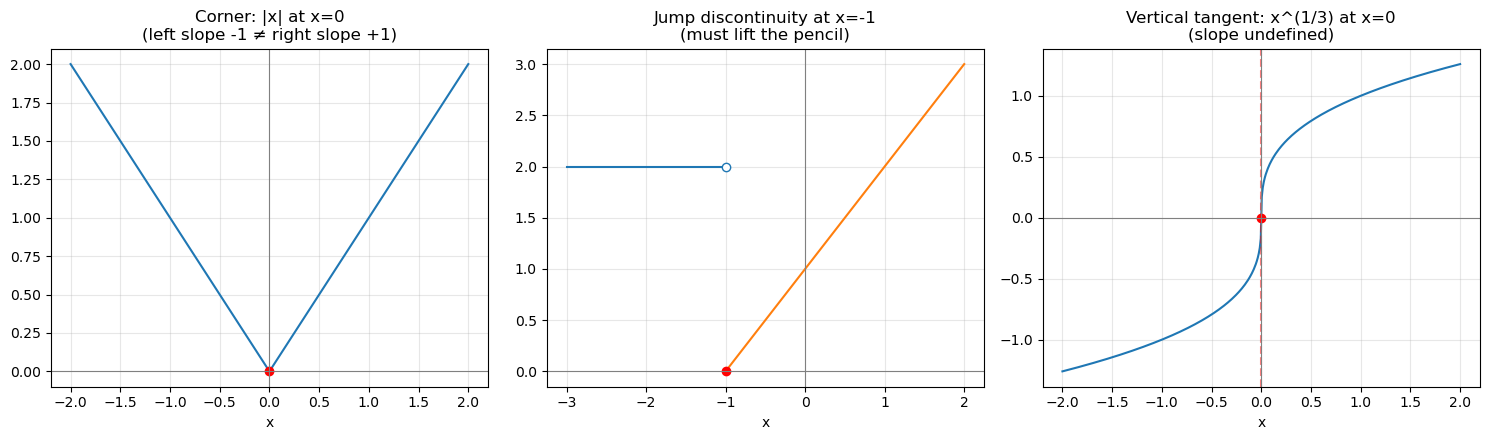

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# corner: |x|
xs = np.linspace(-2, 2, 400)
axes[0].plot(xs, np.abs(xs))
axes[0].plot(0, 0, "ro")
axes[0].set_title("Corner: |x| at x=0\n(left slope -1 ≠ right slope +1)")

# jump
xl = np.linspace(-3, -1, 100); xr = np.linspace(-1, 2, 100)
axes[1].plot(xl, np.full_like(xl, 2))
axes[1].plot(xr, xr + 1)
axes[1].plot(-1, 2, "o", mfc="white", mec="tab:blue")
axes[1].plot(-1, 0, "ro")
axes[1].set_title("Jump discontinuity at x=-1\n(must lift the pencil)")

# vertical tangent
xv = np.linspace(-2, 2, 400)
axes[2].plot(xv, np.cbrt(xv))
axes[2].plot(0, 0, "ro")
axes[2].axvline(0, color="red", ls="--", alpha=0.5)
axes[2].set_title("Vertical tangent: x^(1/3) at x=0\n(slope undefined)")

for ax in axes:
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlabel("x"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary

A function is **not differentiable** at a point if it has any of:

| type | example | why |
|---|---|---|
| **corner / cusp** | $|x|$ at $0$ | one-sided slopes differ — no unique tangent |
| **jump discontinuity** | step function | not continuous — no tangent |
| **vertical tangent** | $x^{1/3}$ at $0$ | slope is undefined (rise / 0) |

> *"Corners and cusps are bad, jump discontinuities are bad, and vertical tangents are
> bad — these are all non-differentiable."*

A single bad point makes the function non-differentiable **there** (and so not
differentiable on any interval containing it).

## 7. Exercises

### Basic
1. State the three ways a function can fail to be differentiable.
2. Why is $|x|$ not differentiable at $0$?

### Intermediate
3. At which point is $f(x) = |x - 3|$ non-differentiable?
4. Is a function with a jump discontinuity continuous? Differentiable?

### Advanced
5. Show numerically that $f(x) = x^{1/3}$ has a vertical tangent at $0$ (slope $\to \infty$).
6. Give an example of a function that is continuous everywhere but not differentiable at one
   point.

## 8. Solutions / Checks

In [5]:
# 2 & 3: corner slopes
for x0 in (0.0,):
    L, R = one_sided_slopes(np.abs, x0)
    print(f"2. |x| at {x0}: left {L:.0f}, right {R:.0f} -> not differentiable")
L, R = one_sided_slopes(lambda t: np.abs(t - 3), 3.0)
print(f"3. |x-3| at 3: left {L:.0f}, right {R:.0f} -> non-differentiable at x=3")

# 5.
print("5. slope of x^(1/3) near 0:", f"{(np.cbrt(1e-9))/1e-9:,.0f}", "-> blows up (vertical tangent)")

print("4. A jump discontinuity is NOT continuous, and not differentiable.")
print("6. f(x) = |x| is continuous everywhere but not differentiable at x=0.")

2. |x| at 0.0: left -1, right 1 -> not differentiable
3. |x-3| at 3: left -1, right 1 -> non-differentiable at x=3
5. slope of x^(1/3) near 0: 1,000,000 -> blows up (vertical tangent)
4. A jump discontinuity is NOT continuous, and not differentiable.
6. f(x) = |x| is continuous everywhere but not differentiable at x=0.


## 9. Conclusion

- A function is **differentiable** at a point only when a **unique tangent** (a well-defined
  slope) exists there.
- It fails in three visually identifiable ways: **corners/cusps**, **jump
  discontinuities**, and **vertical tangents**.
- Continuity is necessary but not sufficient — $|x|$ is continuous yet not differentiable at
  $0$.
- Recognizing these cases matters in optimization, where gradient methods assume the
  derivative exists.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (16).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 1) lecture **existence of the derivative**. Key spoken points, lightly
cleaned:

> You can't always find a derivative at every point; such functions are non-differentiable
> there. A function is differentiable at a point if a unique tangent (hence a derivative)
> exists, and differentiable on an interval if that holds at every point. Example $|x|$ ($x$
> for $x \ge 0$, $-x$ for $x < 0$) is differentiable everywhere except the origin, where the
> corner admits many lines — no well-defined tangent — so the derivative doesn't exist; this
> happens at any corner or cusp. A step/piecewise function ($2$ for $x < -1$, $x + 1$ for $x
> \ge -1$) has a jump discontinuity at $x = -1$: you must lift the pencil, it isn't
> continuous, and no tangent exists. And $x^{1/3}$ has a vertical tangent at $0$, whose slope
> is undefined (rise over zero run). In short, corners/cusps, jump discontinuities, and
> vertical tangents are all non-differentiable.